# From-Scratch Transformer Baseline — Modeling & Training

**AAI-590 Capstone (Module 5)** · Team: Evin Joy, Sabina George, Jagadeesh Kumar Sellapan

This notebook documents the modeling work for the project. It builds a compact
Transformer **answer-selection network implemented from scratch** (custom
multi-head self-attention and encoder blocks — no `nn.Transformer`), trains it on
our cleaned medical multiple-choice corpus, and inspects the results.

The from-scratch model is the project's transparent **baseline**; the primary
system is a compact open-weight LLM adapted with QLoRA (described in the Methods
section). Data cleaning and exploratory analysis are covered in the companion
notebook `data_cleaning_and_eda.ipynb`.

**Pipeline recap:** raw datasets → cleaning & unification (`src/prepare_data.py`) →
EDA (`src/eda.py`) → **from-scratch model (`src/baseline_model.py`) + training
(`src/train_baseline.py`)** ← *this notebook*.

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Resolve the repository root (works from the repo root or /notebooks).
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("Repo:", REPO)
print("PyTorch:", torch.__version__, "| device:", DEVICE)

Repo: /Volumes/Extreme SSD/final project/capstone-medqa
PyTorch: 2.13.0 | device: mps


## 1&nbsp;&nbsp;Load the cleaned multiple-choice corpus

We train on the multiple-choice subset (MedMCQA + MedQA) of the unified corpus
produced by Stage 1. PubMedQA (yes/no/maybe) is excluded from this answer-
selection baseline.

In [2]:
from src import config as C
df = pd.read_parquet(C.PROCESSED_DIR / "unified_medqa.parquet")
mcq = df[df.source.isin(["medmcqa", "medqa"])].copy()
print(f"Multiple-choice questions available: {len(mcq):,}")
display(mcq["source"].value_counts().to_frame("questions"))
mcq[["source","question","option_a","option_b","option_c","option_d","answer_key"]].head(3)

Multiple-choice questions available: 198,357


,questions
source,
medmcqa,186906
medqa,11451


,source,question,option_a,option_b,option_c,option_d,answer_key
0,medmcqa,Chronic urethral obstruction due to benign pri...,Hyperplasia,Hyperophy,Atrophy,Dyplasia,C
1,medmcqa,Which vitamin is supplied from only animal sou...,Vitamin C,Vitamin B7,Vitamin B12,Vitamin D,C
2,medmcqa,All of the following are surgical options for ...,Adjustable gastric banding,Biliopancreatic diversion,Duodenal Switch,Roux en Y Duodenal By pass,D


## 2&nbsp;&nbsp;The from-scratch architecture

`src/baseline_model.py` implements the encoder from first principles. Each
`MultiHeadSelfAttention` module computes scaled dot-product attention over learned
query/key/value projections; each `TransformerBlock` wraps attention and a GELU
feed-forward network in pre-norm residual connections. The `MCQAnswerSelector`
encodes the question with each of the four options and scores them.

In [3]:
from src.baseline_model import MCQAnswerSelector

# A small instance just to inspect the architecture and parameter count.
demo = MCQAnswerSelector(vocab_size=20000, pad_id=0, dim=160, n_heads=4,
                         n_layers=2, ff_dim=320, max_len=96)
print(demo)
print(f"\nTrainable parameters: {demo.num_parameters():,}")

MCQAnswerSelector(
  (encoder): TransformerEncoder(
    (token_emb): Embedding(20000, 160, padding_idx=0)
    (pos_emb): Embedding(96, 160)
    (drop): Dropout(p=0.1, inplace=False)
    (blocks): ModuleList(
      (0-1): 2 x TransformerBlock(
        (norm1): LayerNorm((160,), eps=1e-05, elementwise_affine=True, bias=True)
        (attn): MultiHeadSelfAttention(
          (q_proj): Linear(in_features=160, out_features=160, bias=True)
          (k_proj): Linear(in_features=160, out_features=160, bias=True)
          (v_proj): Linear(in_features=160, out_features=160, bias=True)
          (out_proj): Linear(in_features=160, out_features=160, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (norm2): LayerNorm((160,), eps=1e-05, elementwise_affine=True, bias=True)
        (ff): Sequential(
          (0): Linear(in_features=160, out_features=320, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Line

The diagram below (generated as `figures/fig10_baseline_architecture.png`) summarises the data flow through the network.

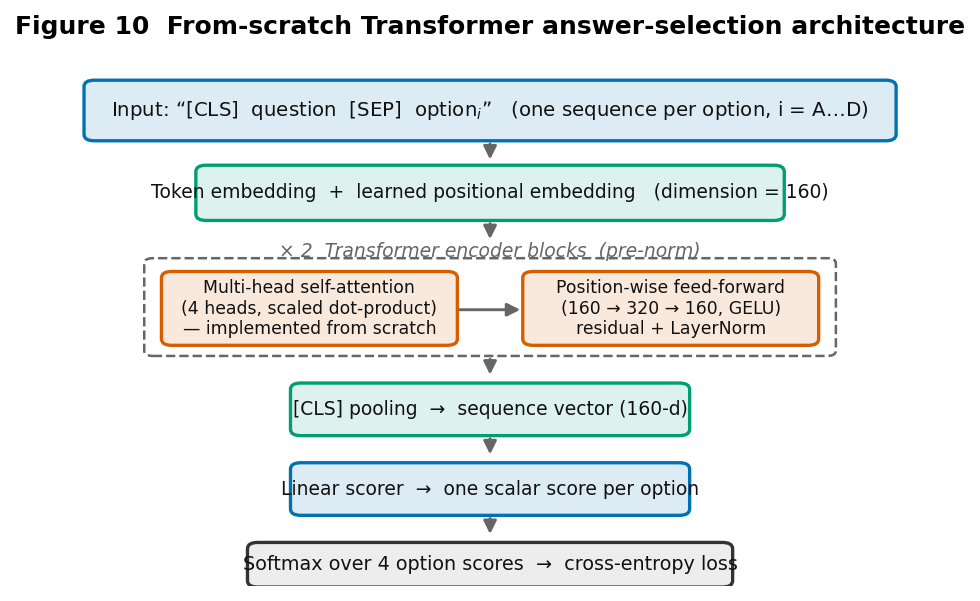

In [4]:
display(Image(filename=str(C.FIG_DIR / "fig10_baseline_architecture.png")))

## 3&nbsp;&nbsp;Tokenization and encoding

We reuse the word-level tokenizer and vocabulary builder from the training module.
Each item becomes four `[CLS] question [SEP] option` id sequences.

In [5]:
from src.train_baseline import (tokenize, build_vocab, encode_pair, build_tensors,
                                  evaluate, HP, PAD, UNK, CLS, SEP)

example_q = mcq.iloc[0]["question"]
print("Question:", example_q[:100])
print("Word tokens:", tokenize(example_q)[:12], "...")

Question: Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in
Word tokens: ['chronic', 'urethral', 'obstruction', 'due', 'to', 'benign', 'prismatic', 'hyperplasia', 'can', 'lead', 'to', 'the'] ...


## 4&nbsp;&nbsp;Train the model (short in-notebook demonstration)

For a fast, self-contained demonstration we train on a small subset for one epoch.
The committed full run (`src/train_baseline.py`, 30k examples × 4 epochs) is shown
in the next section. Both exhibit the same behaviour: a decreasing loss and
above-chance validation accuracy.

In [6]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Small subset for a quick live run.
sub = mcq.sample(frac=1.0, random_state=42).reset_index(drop=True)
train_df, val_df = sub.iloc[:8000], sub.iloc[8000:9000]

stoi = build_vocab(pd.concat([train_df["question"], train_df["option_a"], train_df["option_b"],
                              train_df["option_c"], train_df["option_d"]]), 20000)
Xtr, ytr = build_tensors(train_df, stoi, HP)
Xva, yva = build_tensors(val_df, stoi, HP)
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva, yva), batch_size=64)
print(f"Train {len(train_df):,} | Val {len(val_df):,} | Vocab {len(stoi):,}")

Train 8,000 | Val 1,000 | Vocab 20,000


In [7]:
model = MCQAnswerSelector(vocab_size=len(stoi), pad_id=stoi[PAD], dim=160,
                          n_heads=4, n_layers=2, ff_dim=320, max_len=96).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)

losses, step = [], 0
model.train()
for ids, labels in train_loader:
    ids, labels = ids.to(DEVICE), labels.to(DEVICE)
    optimizer.zero_grad()
    loss = criterion(model(ids), labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    losses.append(loss.item()); step += 1
    if step % 50 == 0:
        print(f"step {step:3d}  loss {np.mean(losses[-50:]):.4f}")

acc = evaluate(model, val_loader)
print(f"\nValidation accuracy: {acc:.3f}  (random chance = 0.250)")

step  50  loss 1.4000


step 100  loss 1.3911


step 150  loss 1.3973


step 200  loss 1.3819


step 250  loss 1.3844



Validation accuracy: 0.271  (random chance = 0.250)


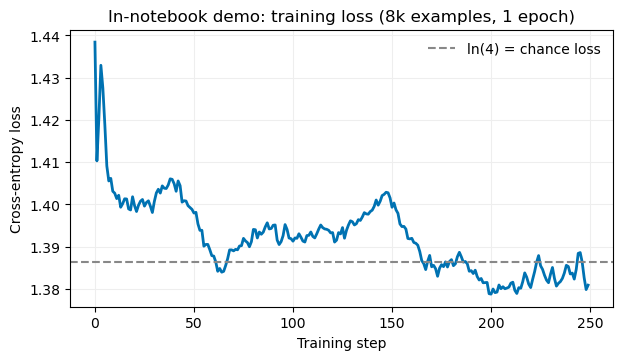

In [8]:
%matplotlib inline
# (re-enable inline plotting: importing the training module set the Agg backend)
# Smoothed training-loss curve for the demo run.
fig, ax = plt.subplots(figsize=(7, 3.6))
s = pd.Series(losses).rolling(25, min_periods=1).mean()
ax.plot(s, color="#0072B2", linewidth=2)
ax.axhline(np.log(4), ls="--", color="#888", label="ln(4) = chance loss")
ax.set_xlabel("Training step"); ax.set_ylabel("Cross-entropy loss")
ax.set_title("In-notebook demo: training loss (8k examples, 1 epoch)")
ax.legend(frameon=False); ax.grid(color="#EEE"); plt.show()

## 5&nbsp;&nbsp;Full training run

The committed run trains on 30,000 examples for four epochs. Its loss/accuracy
curve and summary metrics were saved by `src/train_baseline.py`.

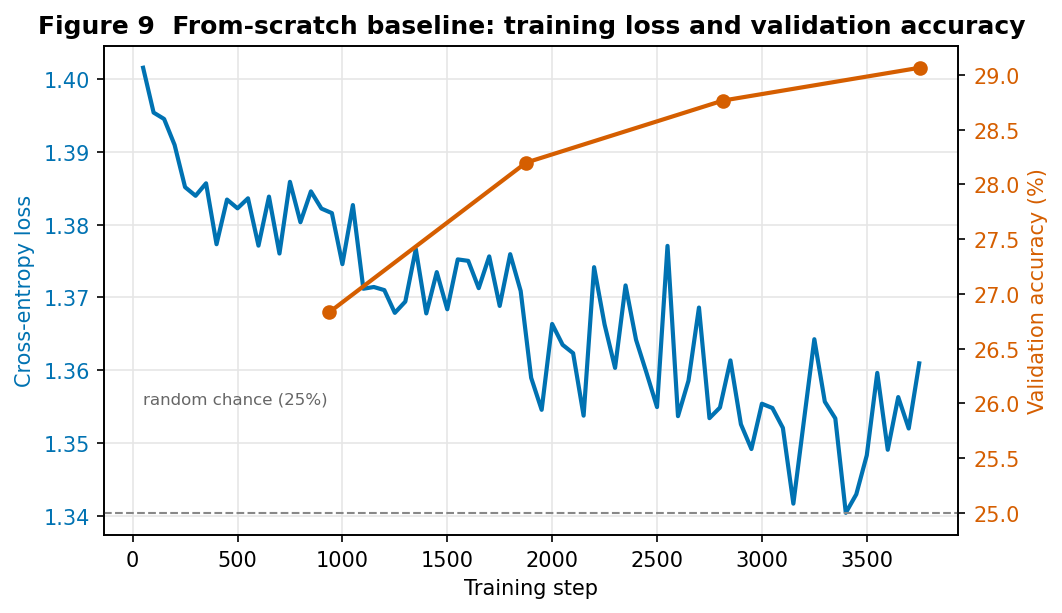

,metric,value
0,device,mps
1,trainable parameters,"3,628,961"
2,epochs,4
3,batch size,32
4,peak learning rate,0.0005
5,chance accuracy,0.250
6,final val accuracy,0.291
7,train seconds,110.4


In [9]:
display(Image(filename=str(C.FIG_DIR / "fig09_baseline_training.png")))

log = json.load(open(C.REPORT_DIR / "baseline_training_log.json"))
pd.DataFrame({
    "metric": ["device", "trainable parameters", "epochs", "batch size",
               "peak learning rate", "chance accuracy", "final val accuracy", "train seconds"],
    "value":  [log["device"], f'{log["trainable_parameters"]:,}', log["hyperparameters"]["epochs"],
               log["hyperparameters"]["batch_size"], log["hyperparameters"]["lr"],
               f'{log["chance_accuracy"]:.3f}', f'{log["final_val_accuracy"]:.3f}',
               log["train_seconds"]]
})

## 6&nbsp;&nbsp;Example predictions

We load the saved full-run checkpoint and apply it to a few validation questions.

In [10]:
ckpt = torch.load(C.ROOT / "models" / "baseline_mcq.pt", map_location=DEVICE, weights_only=False)
saved_stoi, hp = ckpt["stoi"], ckpt["hp"]
trained = MCQAnswerSelector(vocab_size=len(saved_stoi), pad_id=saved_stoi[PAD],
                            dim=hp["dim"], n_heads=hp["n_heads"], n_layers=hp["n_layers"],
                            ff_dim=hp["ff_dim"], max_len=hp["max_len"]).to(DEVICE)
trained.load_state_dict(ckpt["model_state"]); trained.eval()

letters = ["A", "B", "C", "D"]
opt_cols = ["option_a", "option_b", "option_c", "option_d"]
rows = []
for _, r in val_df.head(6).iterrows():
    seqs = [encode_pair(r["question"], r[c], saved_stoi, hp["max_q"], hp["max_opt"], hp["max_len"])
            for c in opt_cols]
    with torch.no_grad():
        logits = trained(torch.tensor([seqs], device=DEVICE))
    pred = letters[int(logits.argmax(1))]
    rows.append({"question": r["question"][:70] + "…", "predicted": pred,
                 "gold": r["answer_key"], "correct": pred == r["answer_key"]})
pd.DataFrame(rows)

,question,predicted,gold,correct
0,Cullen's sign is seen in…,D,C,False
1,Prognosis of schizophrenia depends on-…,A,C,False
2,What dose of radiation therapy is recommended ...,B,A,False
3,Lesh-Nyan syndrome is due to deficiency of: (R...,C,A,False
4,Oschner sherren regime is used in management o...,C,C,True
5,Corneal endothelium seen by ?…,D,D,True


## 7&nbsp;&nbsp;Summary and next steps

- We implemented a Transformer answer-selection network **from scratch** in PyTorch
  and trained it end-to-end on the cleaned medical MCQ corpus; the loss decreases
  and validation accuracy rises above the 25% random-chance level, confirming that
  training works.
- As expected, a small model with no external medical knowledge only modestly
  exceeds chance. This is the intended role of the **baseline**: it sets the
  reference that the knowledge-rich, QLoRA-fine-tuned LLM must beat.
- **Module 6 (optimization):** tune the QLoRA rank/scaling, target modules,
  learning rate, and base-model choice; for the baseline, vary depth/width,
  sequence length, and learning rate. Comparative results will be reported in the
  Results section.

*Use of AI tools:* a generative AI assistant helped scaffold and comment the model
and training code and this notebook; all code was executed and reviewed by the team.